# 10.2.1 极点与根轨迹的低阶例子

## 学习目标与先修知识

从闭环特征方程计算极点（pole），核对增益（gain）和阻尼。

先修：第6.3章传递函数（transfer function）与复数（complex number）频率、第3.2章特征值（eigenvalue），以及10.1闭环。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

同一个负反馈（negative feedback）回路改变增益后，为什么有时响应更快，有时出现明显振荡？只看增益数值不足以判断，应追踪闭环特征根。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

取对象 $G(s)=1/[(s+1)(2s+1)]$，先手算K=0与K=2的特征方程系数。

In [2]:
for K in [0,2]:print(f"K={K}, characteristic coefficients:",[2.,3.,1.+K])

K=0, characteristic coefficients: [2.0, 3.0, 1.0]
K=2, characteristic coefficients: [2.0, 3.0, 3.0]


## 模型假设

线性连续对象的两个稳定极点位于−1与−1/τ，τ>0 T。单位负反馈，控制器为非负常数增益K；此节没有纯延迟（delay）、测量噪声（measurement noise）或饱和。使用Laplace初值（initial condition）为零的输入（input）输出（output）关系；实际性能另需检查。

## 数学解释与推导

单位负反馈的闭环传递函数是 $T(s)=KG(s)/(1+KG(s))$。代入 $G(s)=1/[(s+1)(\tau s+1)]$，得到特征方程
$$\tau s^2+(\tau+1)s+(1+K)=0.$$
其根为 $s_{1,2}=[-(\tau+1)\pm\sqrt{(\tau+1)^2-4\tau(1+K)}]/(2\tau)$。判别式为正时两个实根；为负时复共轭（complex conjugate），实部均为 $-(\tau+1)/(2\tau)<0$。根轨迹（trajectory）是K改变时闭环根的位置集合，不是开环固定极点的路径。

对本节K≥0的特定对象，系数为正且根实部为负。即使如此，增大K可能增强振荡或要求更大执行输入；加入延迟、饱和或模型（model）误差后必须重新分析，不能把本结论直接推广。

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def closed_loop_poles(gain, tau):
    """Unity feedback of G(s)=1/((s+1)(tau*s+1)), tau>0."""
    real = -(tau + 1) / (2 * tau)
    discriminant = (tau + 1) ** 2 - 4 * tau * (1 + gain)
    if discriminant >= 0:
        offset = math.sqrt(discriminant) / (2 * tau)
        return [real - offset, real + offset], [0.0, 0.0]
    offset = math.sqrt(-discriminant) / (2 * tau)
    return [real, real], [-offset, offset]

## 对照实验

随K扫描实部与虚部，另以相同一阶微分模型的数值解比较几组单位阶跃响应。这里保留解析极点作为时域模拟的独立核对。

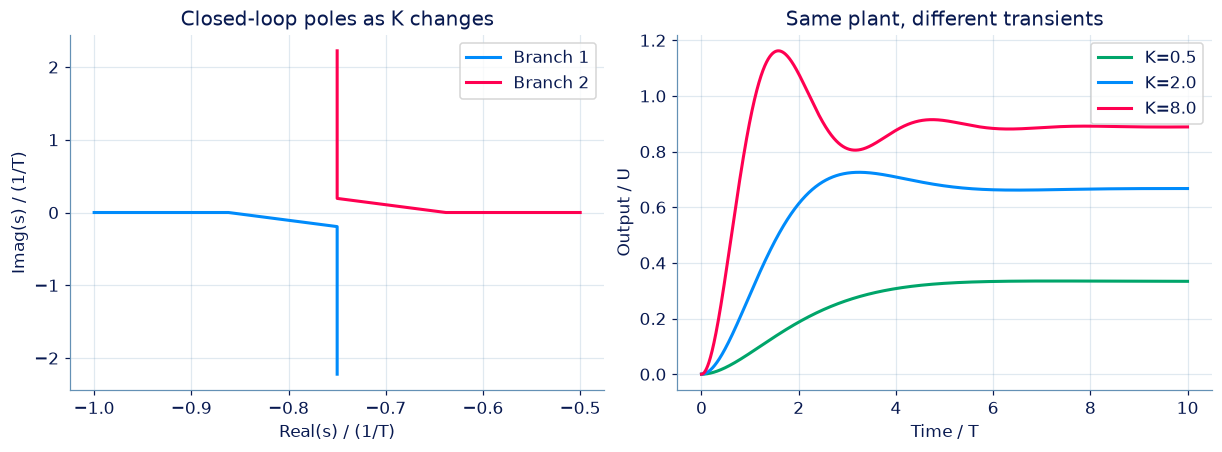

In [4]:
tau=2.;gains=np.linspace(0,10,101);roots=[closed_loop_poles(float(K),tau) for K in gains]
fig,axes=plt.subplots(1,2,figsize=(11,4))
for branch,color in [(0,BLUE),(1,PINK)]:
    axes[0].plot([pair[0][branch] for pair in roots],[pair[1][branch] for pair in roots],color=color,label=f'Branch {branch+1}')
axes[0].set(xlabel='Real(s) / (1/T)',ylabel='Imag(s) / (1/T)',title='Closed-loop poles as K changes');axes[0].legend()
for K,color in [(.5,GREEN),(2.,BLUE),(8.,PINK)]:
    x1=x2=0.;curve=[];h=.002
    for _ in range(5000):
        curve.append(x2)
        next1=x1+h*(-x1+K*(1.-x2));next2=x2+h*(-x2+x1)/tau
        x1,x2=next1,next2
    axes[1].plot(np.arange(5000)*h,curve,label=f'K={K}',color=color)
axes[1].set(xlabel='Time / T',ylabel='Output / U',title='Same plant, different transients');axes[1].legend();plt.show()

## 结果解释

本例极点全部保持在左半平面，但高K对应更明显的复共轭暂态（transient）；稳定不等于单调或低输入代价。右图用小步长 Euler 近似展示这些极点对应的暂态。

### 独立核对

独立以NumPy多项式求根，核对解析实虚部；将时域步长减半以排查可见波形是否由离散误差制造。

In [5]:
for K in [0.,.5,2.,8.]:
    re,im=closed_loop_poles(K,2.)
    calculated=sorted([complex(a,b) for a,b in zip(re,im)],key=lambda z:(round(z.real,10),z.imag))
    independent=sorted(np.roots([2.,3.,1.+K]),key=lambda z:(round(z.real,10),z.imag))
    np.testing.assert_allclose(calculated,independent,atol=1e-12)
print('解析根与独立多项式求根一致。')

解析根与独立多项式求根一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：求闭环极点

单位负反馈（negative feedback），G(s)=1/[(s+1)(τs+1)]，比例增益（gain） K≥0，τ>0。闭环特征方程 τs²+(τ+1)s+(1+K)=0。返回按实部、虚部从小到大排列的一对极点（pole）分量。

**函数与代码模板**

```python
def solve(
    gain: float,
    tau: float,
) -> tuple[list[float], list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gain` | `float` | 比例回路增益 K。 | 1 |
| `tau` | `float` | 第二时间常数 τ。 | T |

**返回值**

按以下顺序返回元组：(real_parts, imag_parts)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `real_parts` | `list[float]` | 两个极点的实部。 | 1/T |
| `imag_parts` | `list[float]` | 两个极点的虚部。 | 1/T |

**计算规则**

用判别式(τ+1)²−4τ(1+K)计算；若负，虚部为正负共轭。返回各列与相同排序的极点配对。

**约束与边界**

- 输入（input）均为有限数；只需实现题定模型（model），不外推到真实病人或设备。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| gain | 比例回路增益 K。 | 0 | 1 |
| tau | 第二时间常数 τ。 | 2 | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
gain = 0.0
tau = 2.0

result = solve(gain, tau)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| real_parts | 两个极点的实部。 | [-1.0, -0.5] | 1/T |
| imag_parts | 两个极点的虚部。 | [0.0, 0.0] | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-1.0, -0.5], [0.0, 0.0])
```

**样例解释**

K=0、τ=2 时根为−1与−0.5；增大K可改变阻尼和振荡，却不能只凭K增加就断言响应单调更好。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：求闭环极点](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-second-order-poles)

### 第 2 题 · 多项选择题：极点与暂态

对于本节线性连续模型（model），两个闭环极点（pole）实部均为负。哪些结论有条件成立？

- **A.** 无未建模动态且模型精确时，小扰动自然响应衰减。
- **B.** 有饱和也一定保持相同的全局稳定结论。
- **C.** 复共轭（complex conjugate）极点对应振荡形状的暂态（transient）分量。
- **D.** 极点位置本身不能说明传感器噪声与执行代价都可接受。

[作答：极点与暂态](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-pole-to-time)

### 第 3 题 · 单项选择题：根轨迹画的是什么

固定对象 G(s)，只改变实数增益（gain） K。根轨迹（trajectory）中的点表示什么？

- **A.** 每个K所对应的闭环特征根。
- **B.** 每个K下开环对象原有极点（pole）必随之移动。
- **C.** 执行器实际输入（input）随时间的轨迹。
- **D.** 同一个频率的相角随时间的轨迹。

[作答：根轨迹画的是什么](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-root-locus-meaning)

### 第 4 题 · 单项选择题：延迟与低阶近似

为研究纯延迟（delay），把它替换为低阶有理近似。下列说法哪个成立？

- **A.** 近似阶次与频率范围会影响相位（phase）和极点（pole）结论，应对照原延迟模型（model）。
- **B.** 一次近似的稳定极点证明任意真实延迟下都稳定。
- **C.** 延迟只改变幅值，不改变相位。
- **D.** 闭环极点与延迟永远无关。

[作答：延迟与低阶近似](http://127.0.0.1:8000/chapters/10-02-%E9%A2%91%E5%9F%9F%E7%A8%B3%E5%AE%9A%E6%80%A7%E4%B8%8E%E8%AE%BE%E8%AE%A1/practice/?question=p10-delay-approximation)

**进一步阅读**

[MIT OpenCourseWare，Feedback Control Systems 课程讲义](https://ocw.mit.edu/courses/16-30-feedback-control-systems-fall-2010/pages/lecture-notes/)：按主题阅读 PID、频域、能控、观测器和线性二次调节；本教材的模型与数值为独立教学例。